# Time Series Modeling with Amazon stock prices


In this notebook, I am exploring time series techniques using daily stock price data for Amazon from 1997 to 2020. My goal is to predict the daily closing price for the stock. This exercise involves the following steps:

1) Data preprocessing
2) Data exploration and Visualization
3) STL (Decomposition)
4) Stationarity Check and transformation
5) Data Smoothing
6) Experimenting with different models
7) Model selection and forecasting

## Data Preprocessing

In this section, I will read the data from the csv file, create the datetime index, and subset column for the closing value. I will get the complete index for the datetime index and impute the missing values by a rolling mean of 7 days.

In [322]:
# Import packages

import numpy as np
import pandas as pd
import os
import warnings

from datetime import datetime
from datetime import timedelta
from dateutil.relativedelta import relativedelta
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

# timeseries imports
from statsmodels.tools.eval_measures import mse
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose, MSTL, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
# Read the data

data_path = os.path.join('/Users/anirudhananda/shruti_study/time_series/project/data', 'amzn_stock_price_2020.csv')
amzn = pd.read_csv(data_path)
amzn.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,0.086458,294000000
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,0.085417,122136000
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,0.081771,109344000
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,0.071354,377064000


In [3]:
# Set the date as the datetime index

amzn['Date'] = pd.to_datetime(amzn['Date'])
amzn.set_index('Date', inplace=True)
amzn.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1997-05-15,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000
1997-05-16,0.098438,0.098958,0.085417,0.086458,0.086458,294000000
1997-05-19,0.088021,0.088542,0.081250,0.085417,0.085417,122136000
1997-05-20,0.086458,0.087500,0.081771,0.081771,0.081771,109344000
1997-05-21,0.081771,0.082292,0.068750,0.071354,0.071354,377064000


In [4]:
# Subset the Adj. Close column

amzn_close = amzn[['Adj Close']]
print(amzn_close.shape)

# Create the complete index

date_index_range = pd.date_range(amzn.index.min(), amzn.index.max())
amzn_close = amzn_close.reindex(date_index_range)

# Filling the missing values in the time series

amzn_close = amzn_close['Adj Close'].fillna(amzn_close['Adj Close'].rolling(window=7, 
                                                               min_periods=1).mean().shift(1))

(5948, 1)


## Data Exploration and Visualization

Next, let's plot the data to see if there appears to be trend and seasonality present in the series. The plot for the sequence shows a clear trend. To visually see if there is a seasonality, I plot each year individually. The `dayofyear` plot across different years shows a seasonal pattern. 

<Axes: title={'center': 'Daily Amazon stock prices'}>

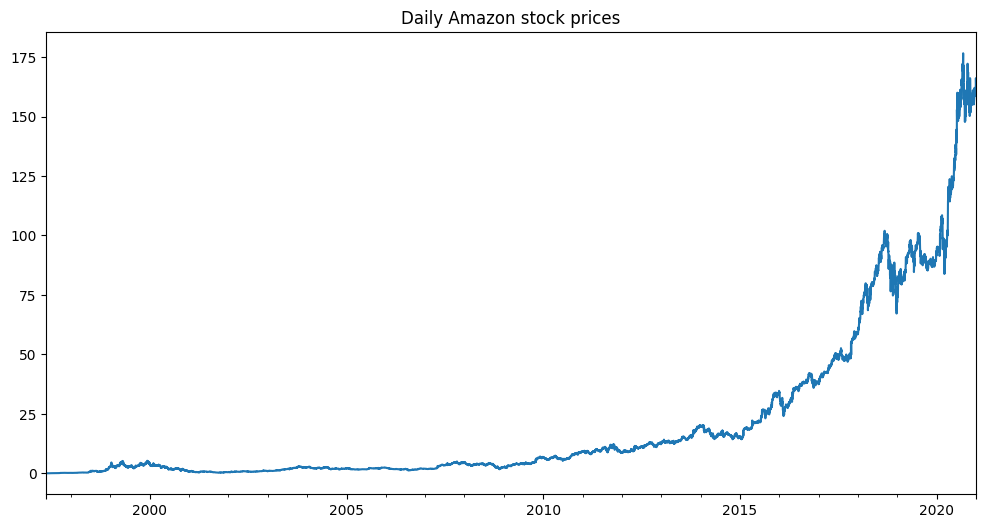

In [5]:
# Plot of sequence

amzn_close.plot(figsize= (12, 6), title = "Daily Amazon stock prices")

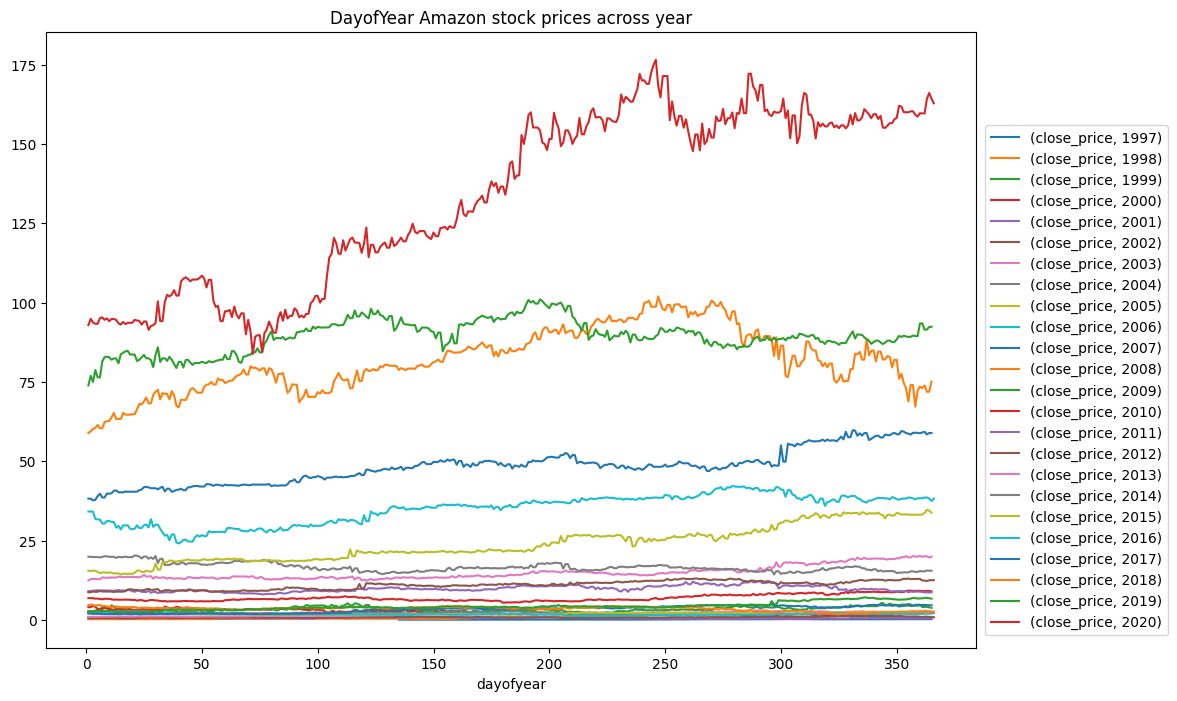

In [6]:
# Pivot the data so we have year as columns

amzn_yr = amzn_close.index.year.to_series().index
amzn_dayofyr = amzn_close.index.dayofyear.to_series().index
amzn_stocks = list(amzn_close.reset_index()['Adj Close'])
amzn_by_year = pd.DataFrame({'dayofyear': amzn_dayofyr, 'year': amzn_yr, 'close_price': amzn_stocks})
amzn_by_year = amzn_by_year.set_index(['dayofyear', 'year']).unstack('year')

# Plot the sequence

amzn_by_year.plot(figsize= (12, 8), title = "DayofYear Amazon stock prices across year").legend(loc=(1.01,0.02))

Let's plot the mean of the series along with the time series, as well as the monthly and quarterly plots. I will need to use the `resample` function to aggregate the data at a monthly and quarterly level first and then use the statsmodels in-built functions.

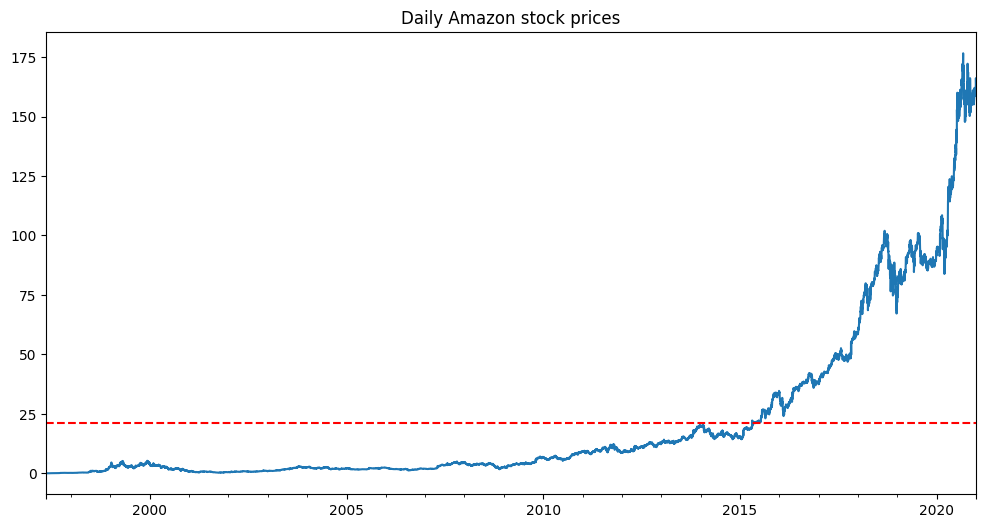

In [7]:
# Plot the sequence with the mean

ax = amzn_close.plot(figsize= (12, 6), title = "Daily Amazon stock prices")
ax.axhline(y = np.mean(amzn_stocks), linestyle = '--', color = 'r')

In [8]:
# Resample at monthly, and quarterly level

amzn_monthly = amzn_close.resample('MS').first()
amzn_quarterly  = amzn_close.resample('QS').first()


Monthly plot for Amazon stock price


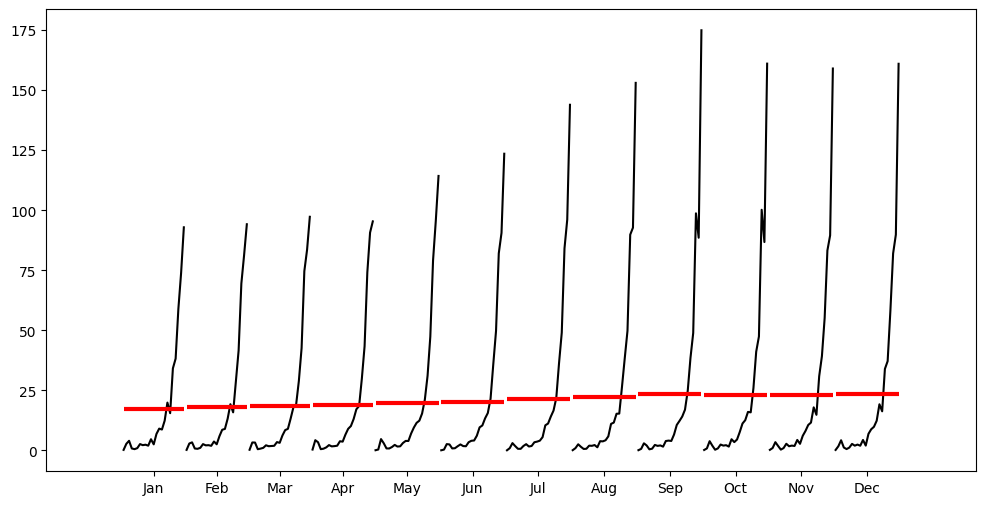

In [9]:
print("\nMonthly plot for Amazon stock price")
plt.rcParams["figure.figsize"] = (12,6)
m_plot = month_plot(amzn_monthly)


Quarterly plot for Amazon stock price


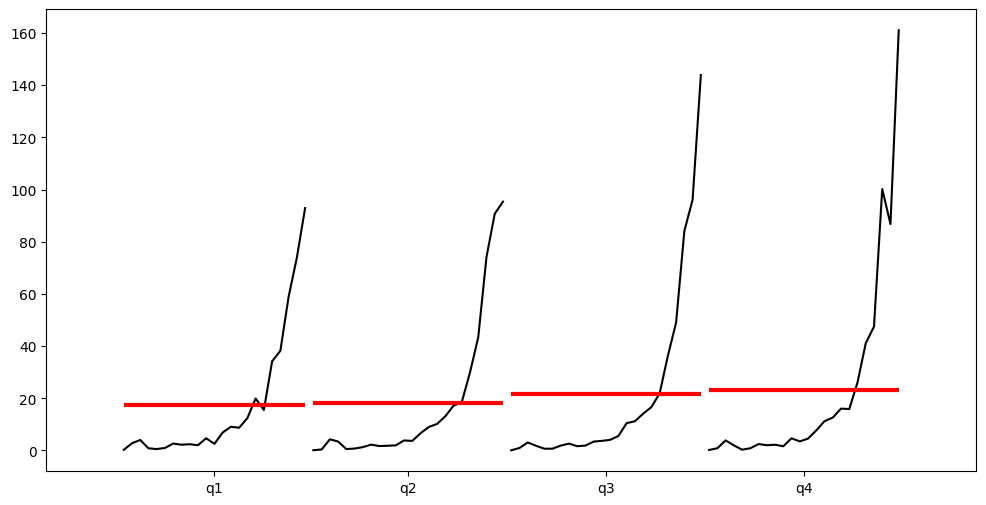

In [10]:
print("\nQuarterly plot for Amazon stock price")
plt.rcParams["figure.figsize"] = (12,6)
q_plot = quarter_plot(amzn_quarterly)

Next, I will plot ACF and PACF. ACF and PACF stand for Autocorrelation Function and Partial Autocorrelation Function. Autocorrelation is the correlation of the current value of a variable to its lagged values. ACF measures the direct and indirect effects whereas PACF only measures the direct effect.

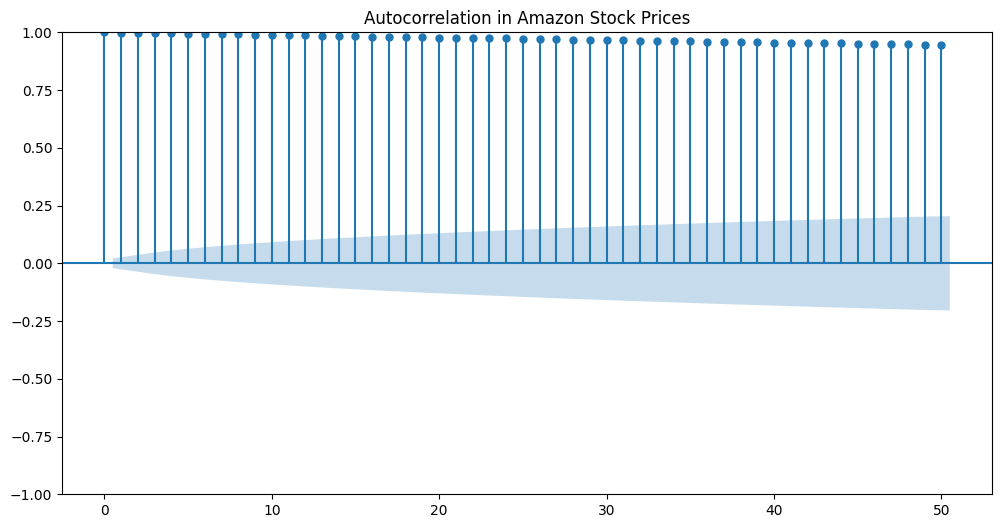

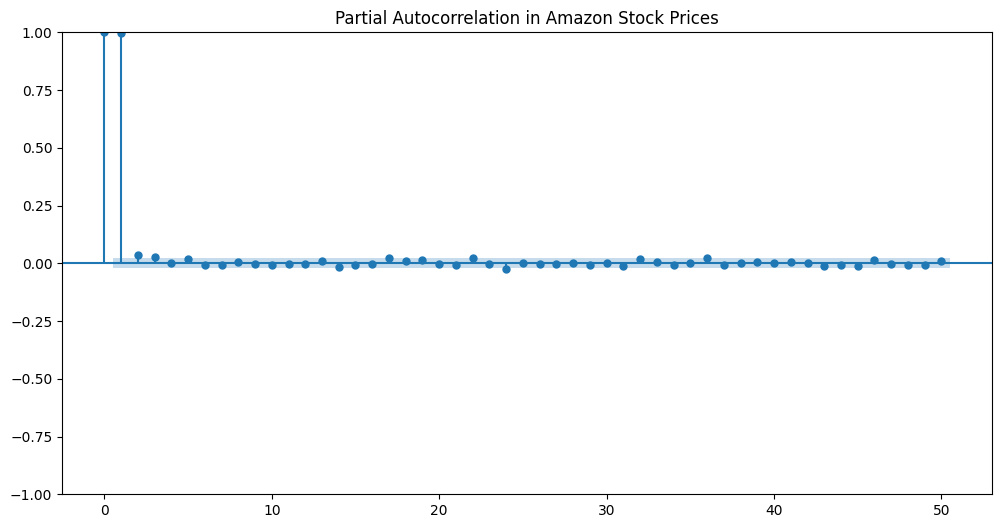

In [11]:
acf_plot = plot_acf(amzn_close, lags=50, title="Autocorrelation in Amazon Stock Prices")
pacf_plot = plot_pacf(amzn_close, lags=50, title="Partial Autocorrelation in Amazon Stock Prices")

## STL - Seasonal Trend Decomposition using LOESS

STL decomposition enables to split the time series into Seasonality, Trend, and Residual. The time series can be decomposed in two different ways - 1) Additive or 2) Multiplicative. We use Additive method when the seaonal variations remains relatively constant over time, otherwise we use the Mutiplicative method. 

In [12]:
stl_decomposition = seasonal_decompose(amzn_close, model='multiplicative', period=365)
est_trend = stl_decomposition.trend
est_seasonal = stl_decomposition.seasonal
est_resid = stl_decomposition.resid

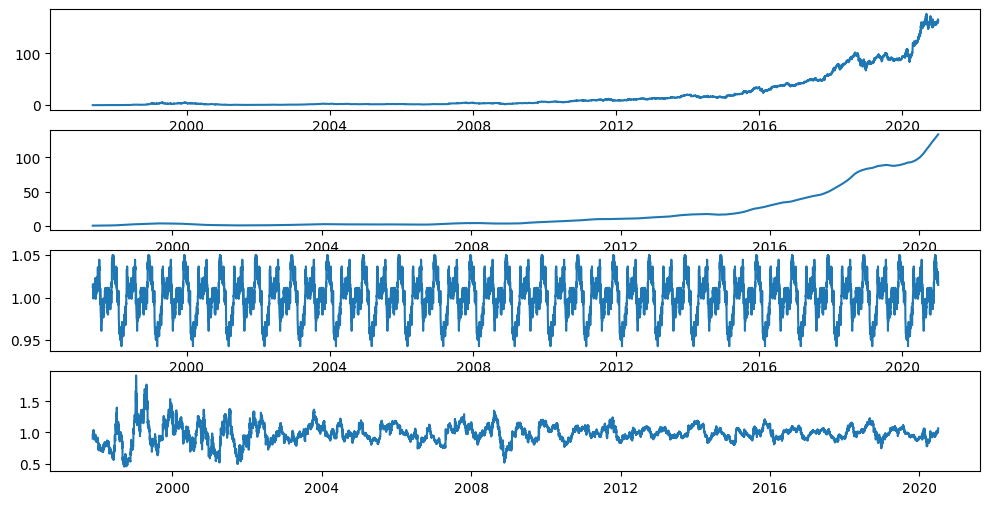

In [13]:
fig, axes = plt.subplots(4, 1)

axes[0].plot(amzn_close)
axes[1].plot(est_trend)
axes[2].plot(est_seasonal)
axes[3].plot(est_resid)

### Stationarity

In order for a time series to be stationary, it must exhibit 4 properties over time:

1. constant mean
2. constant variance
3. constant autocorrelation structure
4. no periodic components

Autocorrelation in time series means that present values are correlated to the past values. Next, I check if the data in stationary or not, by looking at statistics for constant mean and variance. I also perform the `Augmented Dickey-Fuller test`. 


In [31]:
# Break time series to chunks. The np.split method needs to result in equal division.

chunks = np.split(amzn_close, indices_or_sections=26)

print("{} | {:7} | {}".format("Chunk", "Mean", "Variance"))
print("-" * 25)

for i, chunk in enumerate(chunks):
    print('{:5} | {:.4} | {:.4}'.format(i, np.mean(chunk), np.var(chunk)))


Chunk | Mean    | Variance
-------------------------
    0 | 0.1963 | 0.00731
    1 | 1.385 | 0.9995
    2 | 3.532 | 0.4771
    3 | 2.208 | 0.615
    4 | 0.6135 | 0.03257
    5 | 0.7479 | 0.01565
    6 | 1.489 | 0.1956
    7 | 2.411 | 0.07911
    8 | 1.869 | 0.02557
    9 | 2.06 | 0.06041
   10 | 1.891 | 0.1362
   11 | 3.954 | 0.2088
   12 | 3.306 | 0.4571
   13 | 4.839 | 1.303
   14 | 7.007 | 1.094
   15 | 9.885 | 0.9153
   16 | 10.61 | 1.711
   17 | 13.45 | 1.022
   18 | 17.31 | 2.474
   19 | 18.06 | 6.578
   20 | 29.88 | 12.0
   21 | 40.22 | 8.615
   22 | 57.42 | 101.7
   23 | 85.07 | 55.07
   24 | 91.43 | 14.35
   25 | 137.6 | 646.6


The statistics above show that the mean and variance are not constant. This indicates that our time series is not stationary. Next, I plot a histogram with our data. If the histogram looks like a normal distribution, then the data is potentially stationary, otherwise is non-stationary.

<Axes: >

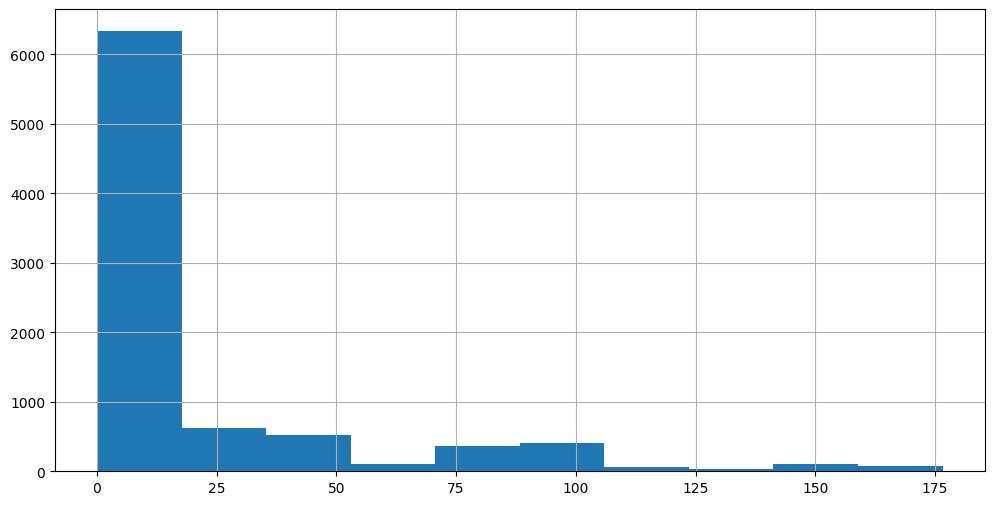

In [32]:
# Histogram plot

pd.Series(amzn_close).hist()

### Augmented Dickey-Fuller Test

Augmented Dickey-Fuller or ADF Test is a statistical test to determine whether the data is stationary or not. 

1. **Null Hypothesis:** the series is nonstationary
2. **Alternate Hypothesis:** the series is stationary

I use 0.05 as the significance level for the test.

In [33]:
# ADF Test

adf, pval, usedlags, nobs, crit_val, ic_best = adfuller(amzn_close)

print("The test statistics is ", format(adf), '\n')
print("The p-value is ", format(pval), '\n')
print("The critical value is ", format(crit_val), '\n')

The test statistics is  5.257870546374957 

The p-value is  1.0 

The critical value is  {'1%': -3.431111141994261, '5%': -2.861876373424649, '10%': -2.566949046643699} 



## Nonstationary to stationary transformations

Based on all the above, I confidently conclude that the stock price data is non-stationary. Next, let's try different approaches to transform the data from non-stationery to stationary. Based on the results below, using residuals as well as differencing the lagged value seems like a good approach.

### Seasonal Decomposition

I already decomposed the data into seasonality, trend, and residuls. One way to transform the data is to remove seasonality and trend component i.e., use the residual. 

In [34]:
# ADF Test using residuals

adf, pval, usedlags, nobs, crit_val, ic_best = adfuller(est_resid[~np.isnan(est_resid)])

print("The test statistics is ", format(adf), '\n')
print("The p-value is ", format(pval), '\n')
print("The number of observation is ", format(nobs), '\n')
print("The critical value is ", format(crit_val), '\n')

The test statistics is  -8.003657029066577 

The p-value is  2.2981771466346466e-12 

The number of observation is  8230 

The critical value is  {'1%': -3.4311448166201597, '5%': -2.861891253347563, '10%': -2.5669569673526453} 



<Axes: >

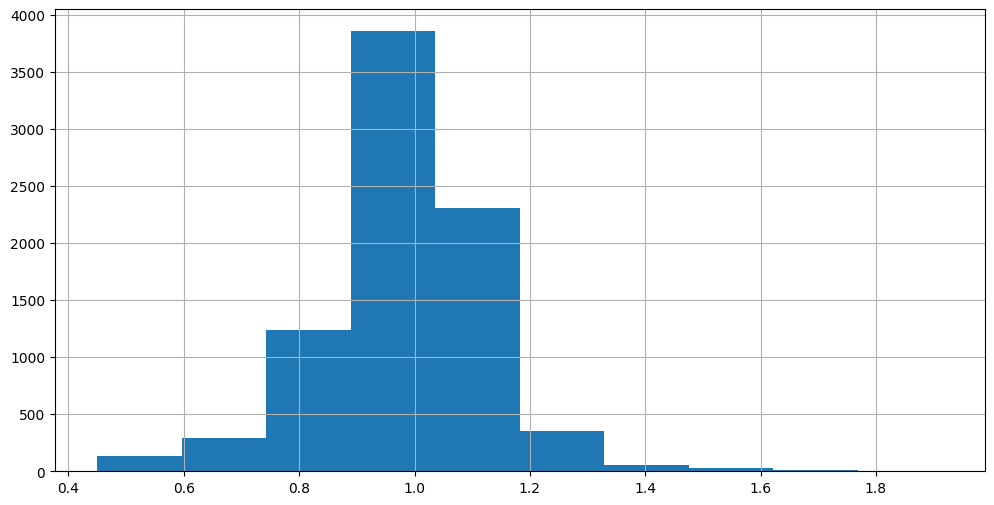

In [35]:
# Histogram plot

pd.Series(est_resid).hist()

### Use log transformation

The log transformation works well when the data is heteroscedastic (i.e, variance is not constant). This is one of the issues in our time series as well.

In [36]:
amzn_close_log = np.log(amzn_close)

# ADF Test using residuals

adf, pval, usedlags, nobs, crit_val, ic_best = adfuller(amzn_close_log)

print("The test statistics is ", format(adf), '\n')
print("The p-value is ", format(pval), '\n')
print("The number of observation is ", format(nobs), '\n')
print("The critical value is ", format(crit_val), '\n')

The test statistics is  -1.7494473181279764 

The p-value is  0.4058324789199711 

The number of observation is  8595 

The critical value is  {'1%': -3.4311110534114224, '5%': -2.861876334282023, '10%': -2.566949025807786} 



<Axes: >

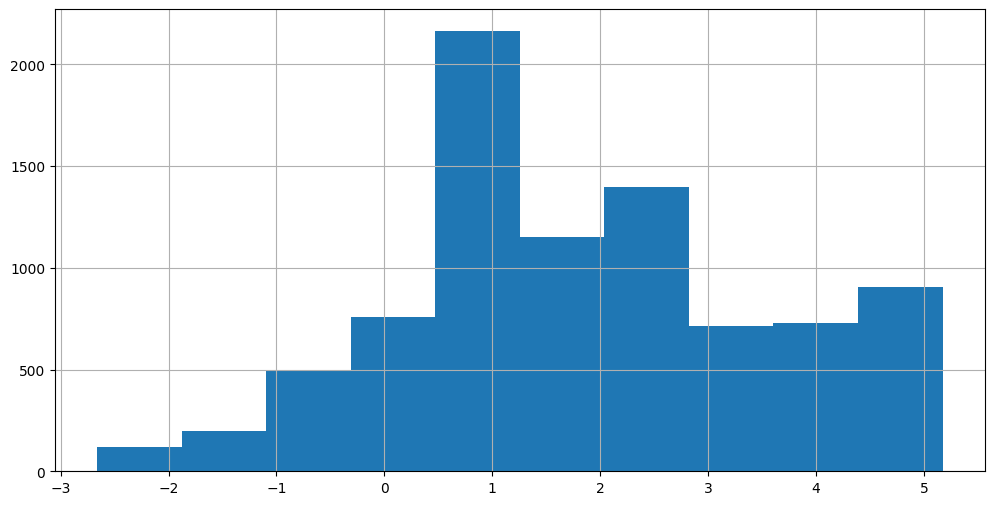

In [37]:
# Histogram plot

pd.Series(amzn_close_log).hist()

### Use differencing to remove Autocorrelation

Autocorrelation can be removed by subtracting the lagged value from the time series. The lagged values are the past observation. The PACF plot above shows that lag values upto 4 have significant correlation to the present values.

In [38]:
lag1 = amzn_close.shift(1)

difference = amzn_close - lag1

# ADF Test using residuals

adf, pval, usedlags, nobs, crit_val, ic_best = adfuller(difference[~np.isnan(difference)])

print("The test statistics is ", format(adf), '\n')
print("The p-value is ", format(pval), '\n')
print("The number of observation is ", format(nobs), '\n')
print("The critical value is ", format(crit_val), '\n')

The test statistics is  -16.27717739115488 

The p-value is  3.4410304685786614e-29 

The number of observation is  8594 

The critical value is  {'1%': -3.431111141994261, '5%': -2.861876373424649, '10%': -2.566949046643699} 



<Axes: >

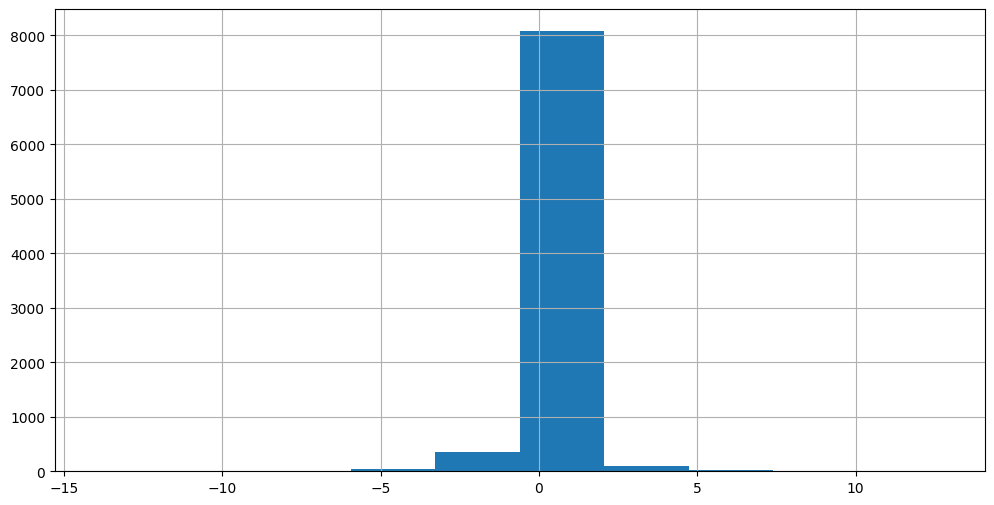

In [39]:
# Histogram plot

pd.Series(difference).hist()

## Forecasting Time Series

Forecasting in time series is predicting future observations. There are different ways for forecasting time series. 

1. Traditional time series techniques
2. Machine Learning
3. Deep Learning

First, I have to split the data into train and test set. I also have tp select a metric to evaluate the predictions. MSE or mean squared error is one such metric.

In [40]:
# Splitting into train and test

train = amzn_close[:round(len(amzn_close)*0.9)]
test = amzn_close[round(len(amzn_close)*0.9):]

### Traditional time series methods

### 1. Smoothing
Smoothing is a technique of extracting patterns from the time series by removing the noise. The simplest smoothing technique is to use the moving average for predicting linear relationship. Exponential smoothing techniques are helpful for non-linear relationships. Exponential smoothing is taking exponentially weighted average of the past values. There are three types of exponential smoothing - Single, Double, and Triple exponential smoothing.


#### Moving Average 

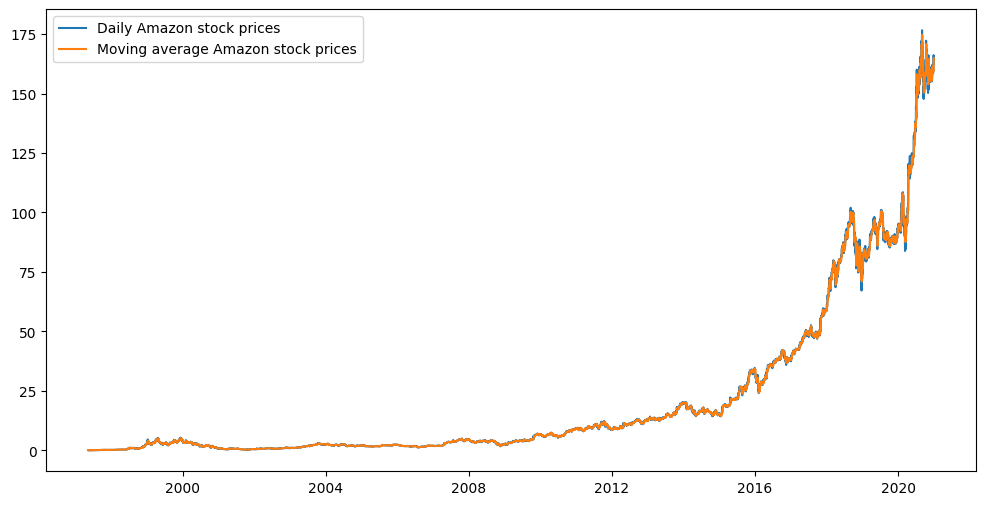

In [41]:
#last = pd.date_range(start=train.index.max(), periods=num_of_test_data + 1, freq='D')

amzn_mov_avg = amzn_close.rolling(window = 3, min_periods=1).mean().shift(1)

plt.plot(amzn_close.index, amzn_close, label="Daily Amazon stock prices")
plt.plot(amzn_close.index, amzn_mov_avg, label="Moving average Amazon stock prices")
plt.legend()

#### Exponential Smoothing


The single smoothing MSE is 1015.1588404554892



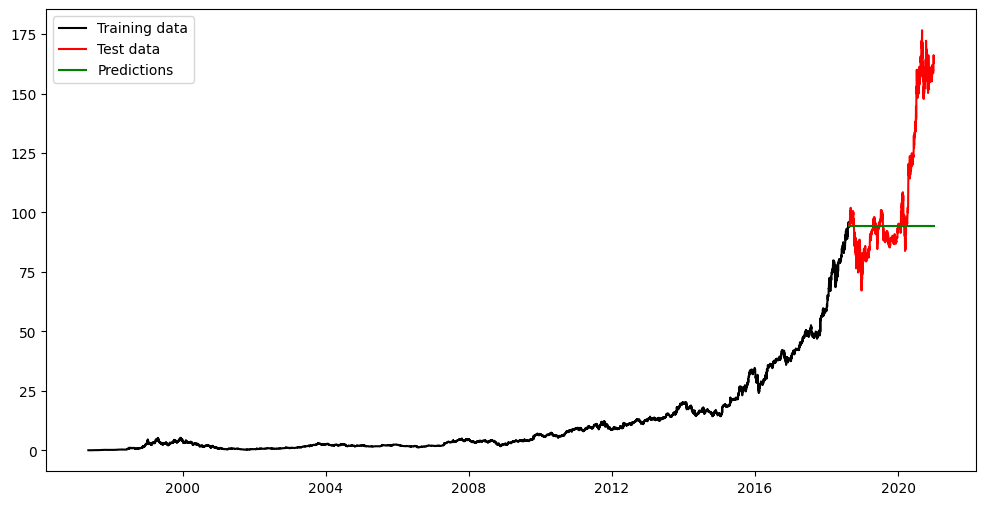

In [289]:
# Single

single = SimpleExpSmoothing(train).fit(optimized=True)
single_preds = single.forecast(len(test))
single_mse = mse(test, single_preds)
print("The single smoothing MSE is {}\n".format(single_mse))

plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(single_preds, color='green', label = 'Predictions')
plt.legend()

The double smoothing MSE is 719.6629032345464\m


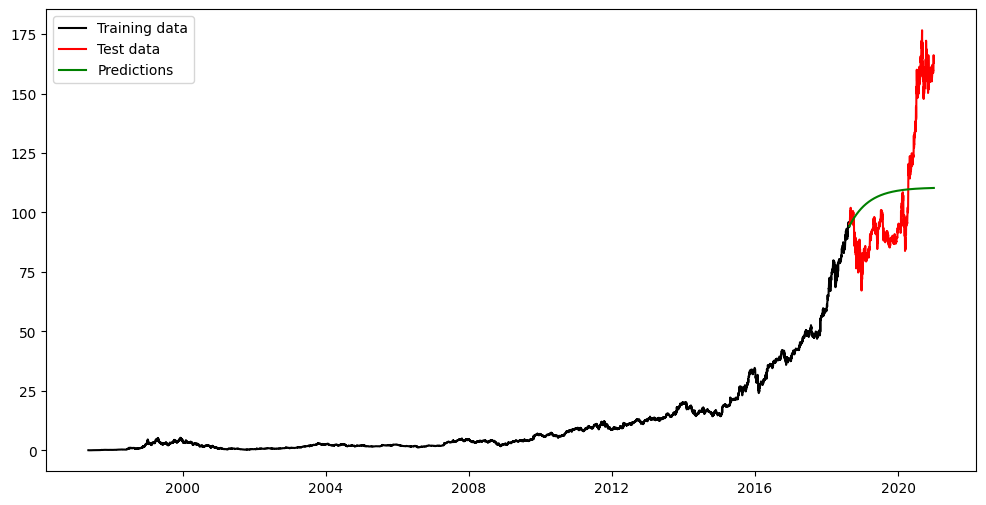

In [290]:
# Double

holt = Holt(train, initialization_method="estimated", damped_trend=True).fit(optimized=True)
holt_preds = holt.forecast(len(test))
holt_mse = mse(test, holt_preds)
print("The double smoothing MSE is {}\m".format(holt_mse))


plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(holt_preds, color='green', label = 'Predictions')
plt.legend()

The triple smoothing MSE is 1015.158847824983



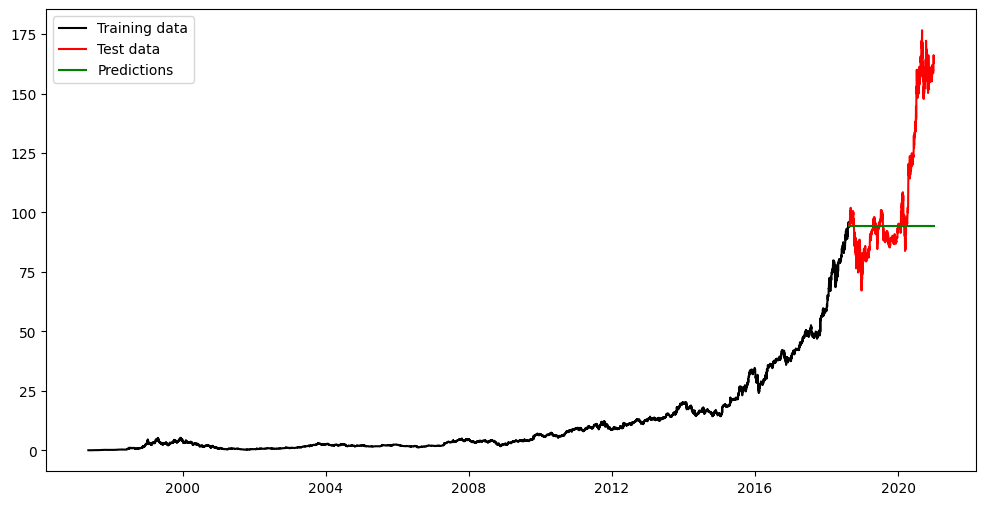

In [45]:
# Holt Winter

triple = ExponentialSmoothing(train).fit(optimized=True)
triple_preds = triple.forecast(len(test))
triple_mse = mse(test, triple_preds)
print("The triple smoothing MSE is {}\n".format(triple_mse))

plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(triple_preds, color='green', label = 'Predictions')
plt.legend()

### 2. AR Model

Autoregression or AR model predict future values using a linear combination of past values. This model usually works well for time series without trend or seasonality.

In [293]:
ar_model = AutoReg(train, lags=2).fit()
ar_pred = ar_model.predict(start= test.index[0], end=test.index[-1])
ar_mse = mse(test, ar_pred)
print("The AR Model MSE is {}".format(ar_mse))

The AR Model MSE is 5256.5581981819605


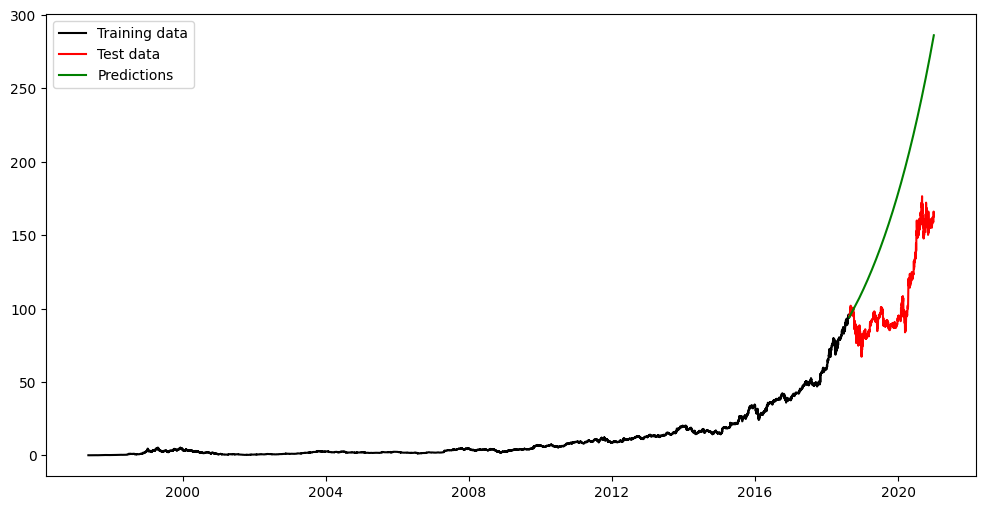

In [294]:
plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(ar_pred, color='green', label = 'Predictions')
plt.legend()

### 3. MA Model

Moving Average or MA model predict future values from previous forcasted errors. The MA model is different than calculating moving average of a time series. The MA model takes a weighted average of the past forecasted errors and fits a model to determine the weights.

In [295]:
ma_model = ARIMA(train, order=(0, 0, 2)).fit()
ma_pred = ma_model.predict(start= test.index[0], end=test.index[-1])
ma_mse = mse(test, ma_pred)
print("The MA Model MSE is {}".format(ma_mse))

The MA Model MSE is 10103.712709317468


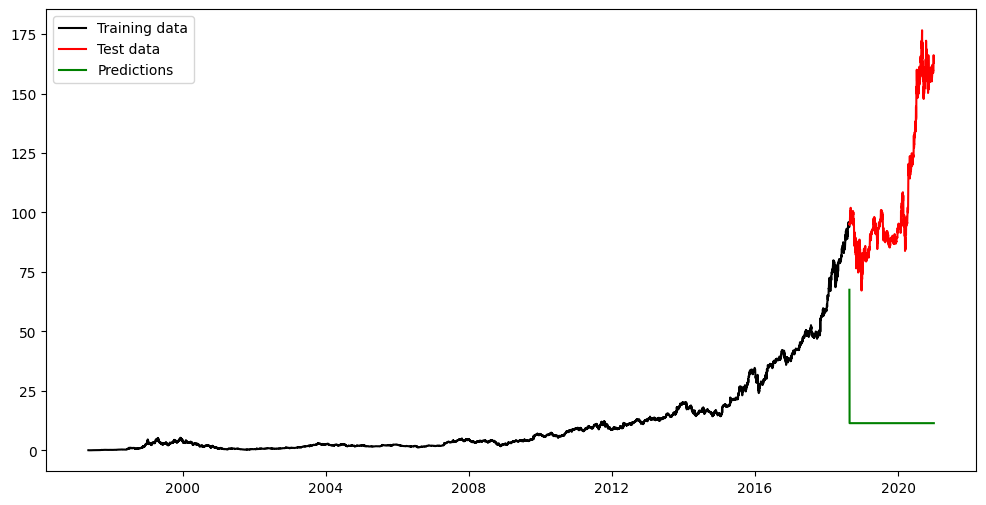

In [296]:
plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(ma_pred, color='green', label = 'Predictions')
plt.legend()

### 4. ARMA Model

Auto Regression Moving Average or ARMA model predict future values as a linear combination of both past values as well as past forecasted errors. The ARMA models are suitable for both stationary as well as non-stationary data and its parameters are estimated using MLE (Maximum Likelihood Estimation).

In [316]:
arma_model = ARIMA(train, order=(2, 0, 2)).fit()
arma_pred = arma_model.predict(start= test.index[0], end=test.index[-1])
arma_mse = mse(test, arma_pred)
print("The ARMA Model MSE is {}".format(arma_mse))

The ARMA Model MSE is 1017.8770530464985


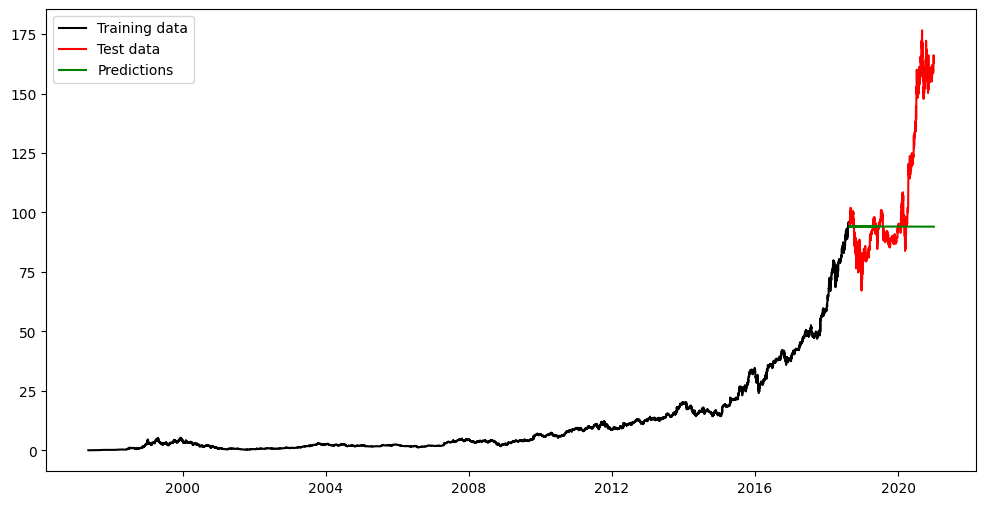

In [317]:
plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(arma_pred, color='green', label = 'Predictions')
plt.legend()

### 5. ARIMA Model

Auto Regression Integrated Moving Average or ARIMA model predict future values using the linear combination of differenced observation and past forecasted residuals. This method includes a differencing pre-processing step to make the sequence stationary, called Integration.

In [313]:
arima_model = ARIMA(train, order=(1, 2, 2)).fit()
arima_pred = arima_model.predict(start= test.index[0], end=test.index[-1])
arima_mse = mse(test, arima_pred)
print("The ARIMA Model MSE is {}".format(arima_mse))

The ARIMA Model MSE is 622.4805922363797


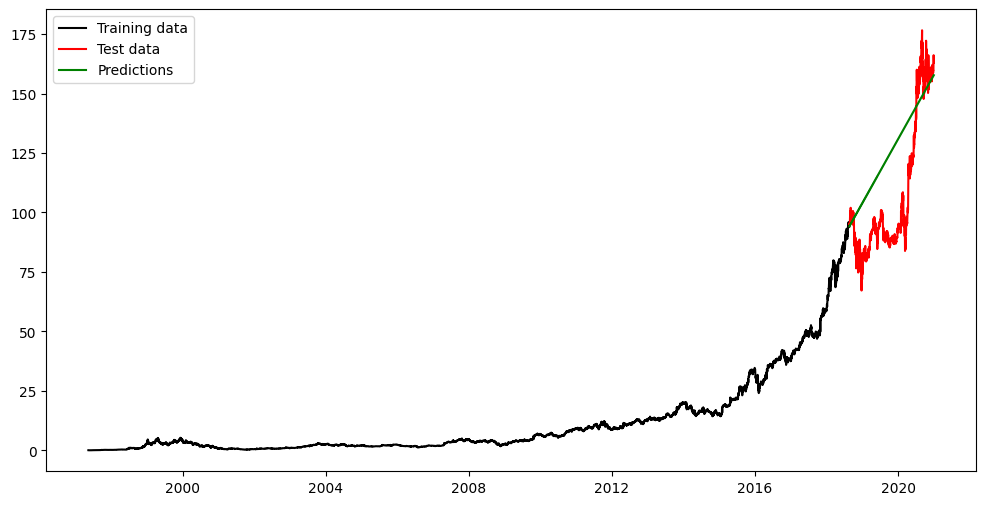

In [314]:
plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(arima_pred, color='green', label = 'Predictions')
plt.legend()

### 6. SARIMA Model

SARIMA model is an extension of ARIMA model that accounts for seasonal trends in the data. It has an additional parameters for seasonal component of the data.

In [320]:
sarima_model = SARIMAX(train, order=(1, 2, 2), seasonal_order=(1,1,1,7)).fit()
sarima_pred = sarima_model.predict(start= test.index[0], end=test.index[-1])
sarima_mse = mse(test, sarima_pred)
print("\nThe SARIMA Model MSE is {}".format(sarima_mse))

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.31374D+00    |proj g|=  2.23709D+00


 This problem is unconstrained.



At iterate    5    f=  5.86349D-01    |proj g|=  1.38887D+00

At iterate   10    f=  4.36853D-01    |proj g|=  1.48698D-01

At iterate   15    f=  4.16343D-01    |proj g|=  1.29223D-02

At iterate   20    f=  4.15035D-01    |proj g|=  3.75800D-03

At iterate   25    f=  4.14670D-01    |proj g|=  1.66489D-03
  ys=-6.576E-06  -gs= 4.450E-06 BFGS update SKIPPED

At iterate   30    f=  4.14664D-01    |proj g|=  2.97969D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    6     31     53      1     1     0   4.096D-04   4.147D-01
  F =  0.41466443393643232     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             

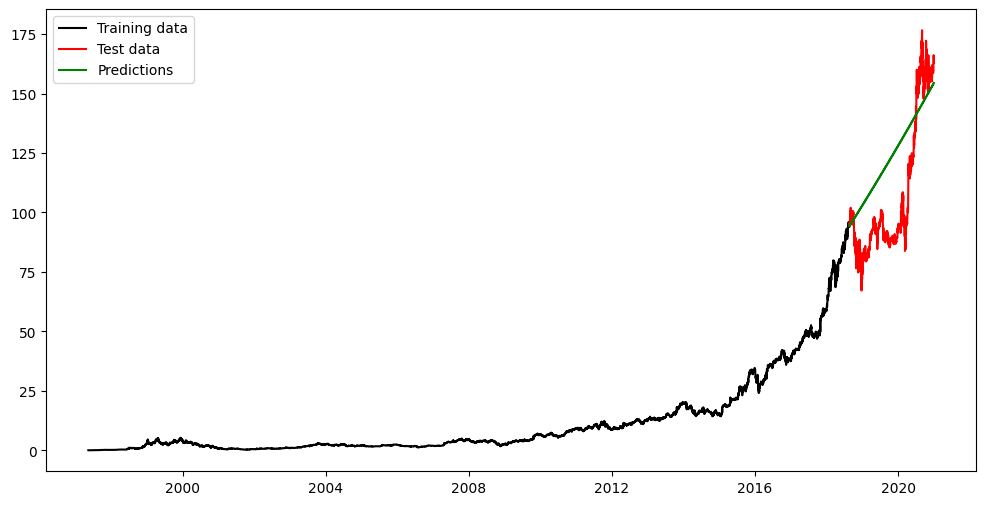

In [321]:
plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(sarima_pred, color='green', label = 'Predictions')
plt.legend()

### Machine Learning techniques

Next, I will employ machine learning models to learn the pattern in different time series components. I will try linear, quadratic and cubic function for trend. For seasonality, I will use dummy indicators and fourier features. For both of these, I will use Linear Regression model. Next, I will use XGBoost for predict the residuals. Finally, I will combine these to get a Hybrid model to predict the closing price for Amazon stocks.

In [275]:
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from sklearn.linear_model import LinearRegression
from scipy.signal import periodogram

dp_trend = DeterministicProcess(
    index=train.index,
    constant=True,
    order=3,
    drop=True)

X = dp_trend.in_sample()

y = (pd.DataFrame(train))['Adj Close']

trend_model = LinearRegression(fit_intercept=False).fit(X, y)
y_trend = pd.Series(trend_model.predict(X), index=X.index)

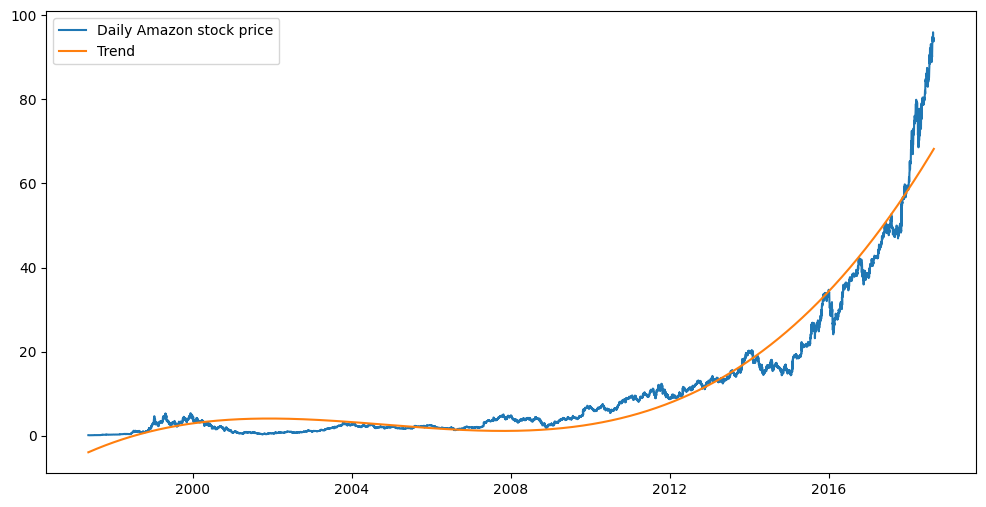

In [276]:
plt.plot(train, label='Daily Amazon stock price')
plt.plot(y_trend, label = "Trend")
plt.legend()

In [277]:
X_test = dp_trend.out_of_sample(steps=len(test))

y_pred_trend = pd.Series(trend_model.predict(X_test), index=X_test.index)
trend_mse = mse(test, y_pred_trend)
print("\nThe MSE for predicted trend is {}".format(trend_mse))


The MSE for predicted trend is 715.388986771622


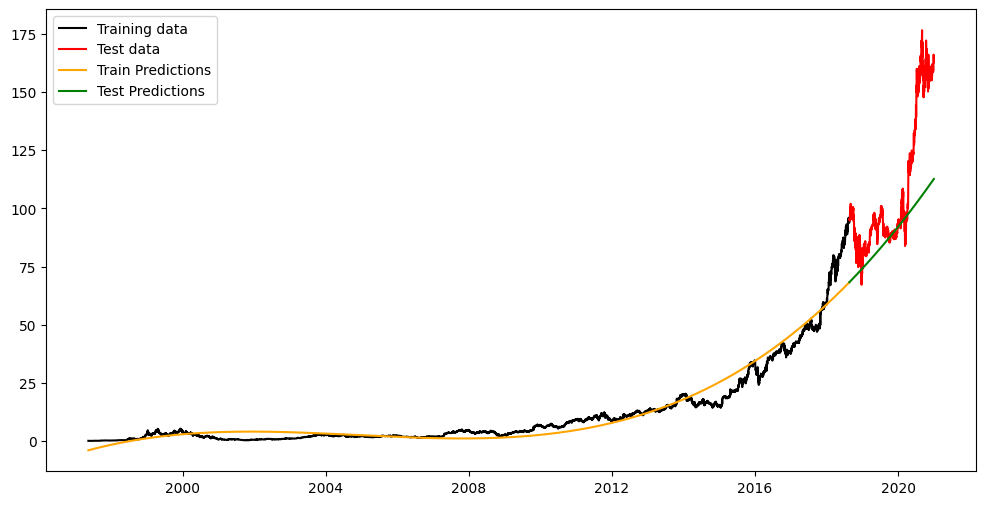

In [278]:
plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(y_trend, color='orange', label = 'Train Predictions')
plt.plot(y_pred_trend, color='green', label = 'Test Predictions')
plt.legend()

<module 'matplotlib.pyplot' from '/Users/anirudhananda/miniconda3/lib/python3.10/site-packages/matplotlib/pyplot.py'>

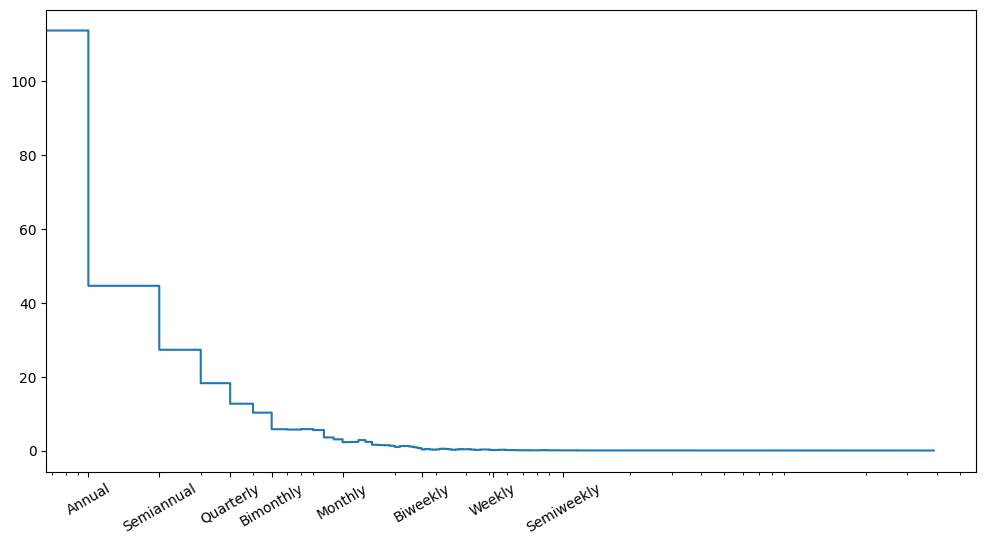

In [279]:
# Function to plot periodogram

from scipy.signal import periodogram
def plot_periodogram(ts, detrend='constant'):
    fs = pd.Timedelta("7769D") / pd.Timedelta("1D")
    freq, spec = periodogram(
        ts,
        fs = fs,
        detrend=detrend,
        window='boxcar',
        scaling='spectrum'
    )
    plt.step(freq, spec)
    plt.xscale("log")
    plt.xticks([1, 2, 4, 6, 12, 26, 52, 104],
               labels =['Annual', 'Semiannual', 
                        'Quarterly', 'Bimonthly', 
                        'Monthly', 'Biweekly', 
                        'Weekly', 'Semiweekly'],
               rotation=30)
    return plt


plot_periodogram(train.to_period("D"))  


In [283]:
fourier = CalendarFourier(freq='A', order=2)
print(fourier)

dp_seas = DeterministicProcess(
    index=train.index,
    constant=True,
    order=3,
    seasonal=True,
    additional_terms=[fourier],
    drop=True)

X = dp_seas.in_sample()

y = (pd.DataFrame(train))['Adj Close']

seasonal_model = LinearRegression(fit_intercept=False).fit(X, y)
y_seasonal = pd.Series(seasonal_model.predict(X), index=X.index)

Fourier(freq=YE-DEC, order=2)


In [284]:
X_test = dp_seas.out_of_sample(steps=len(test))

y_pred_seasonal = pd.Series(seasonal_model.predict(X_test), index=X_test.index)
seasonal_mse = mse(test, y_pred_seasonal)
print("\nThe MSE for predicted trend and seasonality is {}".format(seasonal_mse))


The MSE for predicted trend and seasonality is 717.7335994102209


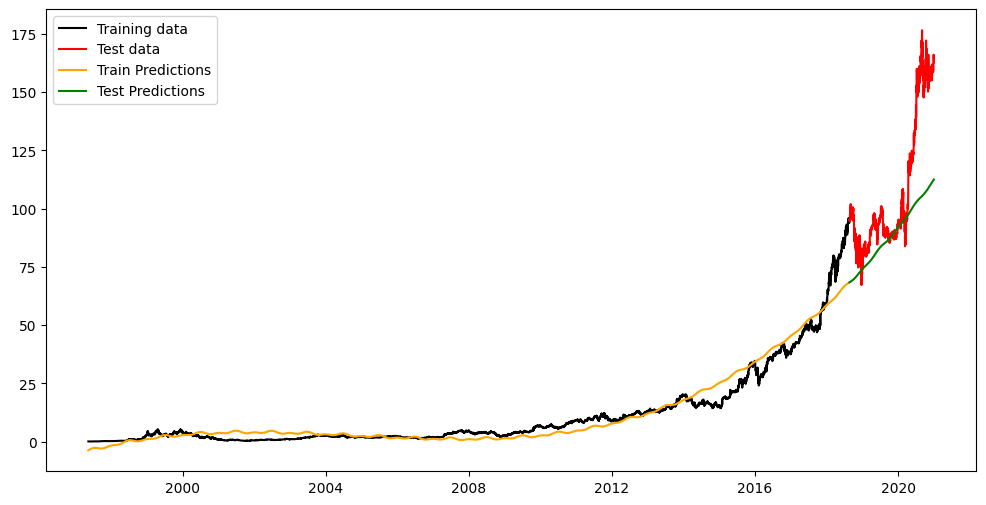

In [286]:
plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(y_seasonal, color='orange', label = 'Train Predictions')
plt.plot(y_pred_seasonal, color='green', label = 'Test Predictions')
plt.legend()

In [328]:
len(X)

7769

In [337]:
train_pred = pd.Series(seasonal_model.predict(X), index=X.index)
y_resid = train - train_pred

xgb = XGBRegressor().fit(X, y_resid)

y_boosted = xgb.predict(X) + y_seasonal
y_pred_boosted = xgb.predict(X_test) + y_pred_seasonal
hybrid_mse = mse(test, y_pred_boosted)
print("\nThe MSE for hybrid ML model is {}".format(hybrid_mse))


The MSE for hybrid ML model is 328.88542979858204


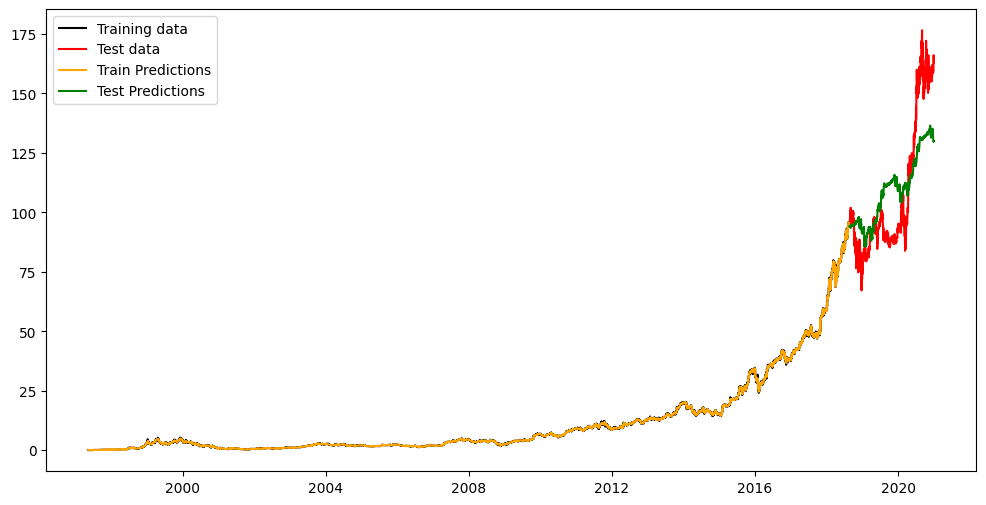

In [338]:
plt.plot(train, color = "black", label='Training data')
plt.plot(test, color = "red", label='Test data')
plt.plot(y_boosted, color='orange', label = 'Train Predictions')
plt.plot(y_pred_boosted, color='green', label = 'Test Predictions')
plt.legend()